# Автоматизация витрины данных по поездкам Яндекс Такси



## Описание проекта

В рамках проекта разработан автоматизированный пайплайн обработки данных о поездках Яндекс Такси.

С помощью PySpark данные из S3 в формате Parquet агрегируются по способам оплаты: рассчитываются количество поездок, средняя стоимость поездки, средние чаевые и суммарная выручка. Полученная витрина taxi_payment_summary загружается в ClickHouse через JDBC.

Для автоматизации процесса настроен DAG в Apache Airflow, который ежедневно проверяет наличие новых данных в S3 и после их появления запускает Spark-задачу. Итоговая витрина может использоваться как источник данных для финансовой отчётности и аналитических дашбордов.

## Описание данных

Таблица `taxi_data` содержит данные об активности пользователей и состоит из следующих полей:



## Задачи проекта

1. Разработать **PySpark-скрипт** для обработки данных о поездках и агрегации показателей по способам оплаты `payment_type`.
2. Рассчитать ключевые метрики:

   * количество поездок;
   * среднюю стоимость поездки;
   * средний размер чаевых;
   * суммарную выручку.
3. Сформировать итоговую витрину `taxi_payment_summary`.
4. Настроить загрузку витрины в **ClickHouse** через JDBC.
5. Создать **DAG в Apache Airflow** для ежедневного запуска пайплайна.
6. Настроить проверку наличия новых данных в **S3** перед запуском Spark-задачи.
7. Обеспечить автоматическое обновление итоговой витрины для дальнейшего использования в отчётности и аналитических дашбордах.


## Настраиваем Spark-агрегацию

Читаем данные формата Parquet. 

Сгруппируем данные по полю `payment_type` и рассчитайте четыре показателя:

* количество поездок — `count(*)`;
* среднюю стоимость — `avg(...)`;
* средние чаевые — `avg(...)`;
* суммарную выручку — `sum(...)`.

В итоге получится витрина для анализа информации по каждому способу оплаты. После этого настроим запись полученной таблицы в ClickHouse.

In [ ]:
CREATE TABLE taxi_payment_summary
(
    payment_type String,
    trip_count Int64,
    avg_fare Float32,
    avg_tips Float32,
    total_revenue Float64
)
ENGINE = MergeTree()
ORDER BY payment_type;

In [ ]:
#filename=my_spark_job.py

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# Создаем spark-сессию
spark = (
    SparkSession.builder
    .appName("taxi_payment_summary")
    .config("fs.s3a.endpoint", "storage.yandexcloud.net")
    .getOrCreate()
)

# Параметры подключения к ClickHouse
jdbcPort = 8443
jdbcHostname = "CLICKHOUSE_HOST"
username = "CLICKHOUSE_USER"
password = "aaa111"
jdbcDatabase = "CLICKHOUSE_DATABASE"
jdbcUrl = f"jdbc:clickhouse://{jdbcHostname}:{jdbcPort}/{jdbcDatabase}?ssl=true"

# Читаем исходные данные о поездках такси из s3
df = spark.read.parquet("s3a://da-plus-dags/project_04/taxi_data.parquet")

# Группируем по типу оплаты и считаем агрегаты
result_df = ( df.groupBy("payment_type").agg(
    F.count("*").alias("trip_count"),
    F.avg("fare").alias("avg_fare"),
    F.avg("tips").alias("avg_tips"),
    F.sum("trip_total").alias("total_revenue"),)
)

# overwrite - для перезаписи таблицы при каждом запуске
result_df.write.format("jdbc") \
    .option("url", jdbcUrl) \
    .option("user", username) \
    .option("password", password) \
    .option("dbtable", "taxi_payment_summary") \
    .option("createTableOptions", "ENGINE=MergeTree() ORDER BY payment_type") \
    .mode('overwrite') \ 
    .save()

## Настраиваем DAG

В DAG используем сенсор `S3KeySensor`, чтобы дождаться появления файла в S3. 

In [ ]:
#filename=my_spark_job.py

from datetime import datetime

from airflow import DAG
from airflow.sensors.s3_key_sensor import S3KeySensor
from airflow.providers.yandex.operators.dataproc import DataprocCreatePysparkJobOperator

DAG_ID = "taxi_payment_summary_daily"

# Имя пользователя вынесено в переменную, чтобы не дублировать его в пути к скрипту
USERNAME = "USER_NAME"

with DAG(
    dag_id=DAG_ID,
    # Запуск каждый день в 16:00
    schedule="0 16 * * *",
    start_date=datetime(2025, 1, 1),
    catchup=False,
) as dag:

# Ждём появления файла с данными такси в S3 перед запуском PySpark кода
    wait_for_input = S3KeySensor(
        task_id="data_s3_sensor",
        poke_interval=60*5,
        timeout=60*60,
        bucket_name="da-plus-dags",
        bucket_key="project_04/taxi_data.parquet",
        mode="poke",
        aws_conn_id="s3",
        wildcard_match=False,
    )

# Запускаем PySpark код
    run_pyspark = DataprocCreatePysparkJobOperator(
        task_id="create_pyspark_job",
        name="taxi_payment_summary_job",
        cluster_id="CLUSTER_ID",
        main_python_file_uri=f"s3a://da-plus-dags/{USERNAME}/jobs/my_spark_job.py",
    )

    wait_for_input >> run_pyspark

## Запустите DAG в Airflow 

Проверяем результат в ClickHouse

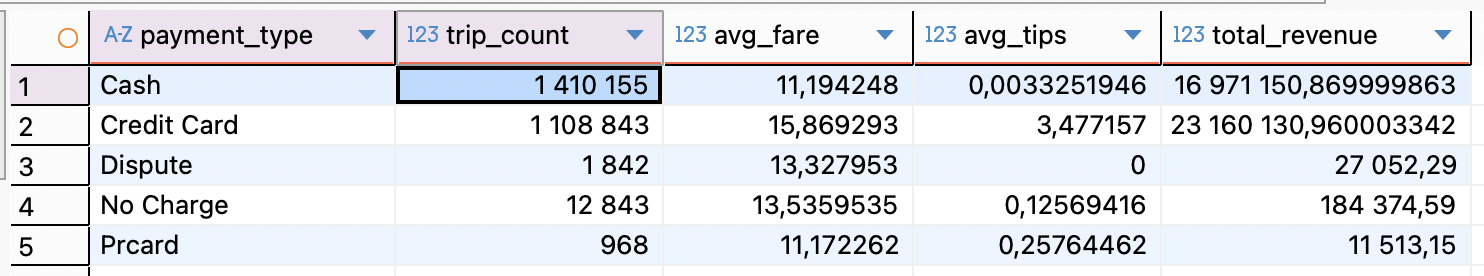